In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
import yfinance as yf
warnings.filterwarnings('ignore')
%matplotlib inline

In [229]:
end = dt.date.today()
start = end - dt.timedelta(days=365*5)
df = yf.download('RELIANCE.NS', start, end,auto_adjust=True)
df.columns = df.columns.droplevel(1)
df.columns = df.columns.str.lower()
df = df.drop(columns=['high','low','open','volume'])
df.index = pd.to_datetime(df.index)

[*********************100%***********************]  1 of 1 completed


In [230]:
df1 = df.copy()

# Moving Average Crossover

Buy and Hold Returns =  0.5055318319663225
Crossover Strategy Returns = 0.10198052361287924
Total Entries: 131
Total Exits: 131


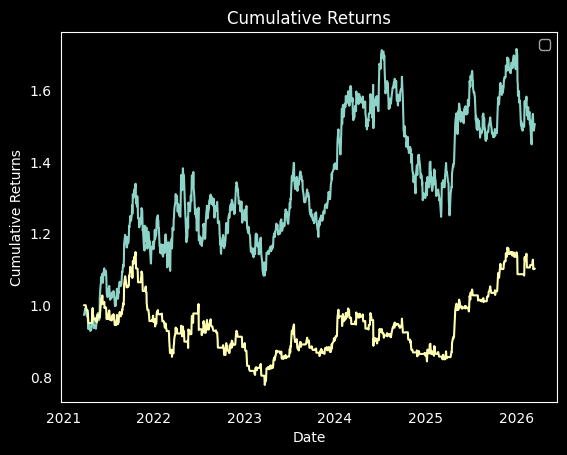

In [231]:
# Yesterday Price
df['yesterday_price'] = df['close'].shift(1)

# Returns
df['pct_change'] = df['close']/df['yesterday_price']-1

# Moving Averages
s_ma = 3
l_ma = 5
df['20sma'] = df['close'].rolling(s_ma).mean()
df['50lma'] = df['close'].rolling(l_ma).mean()

#
df['signal'] = np.where(df['20sma'] > df['50lma'], 1, 0)
df['position'] = df['signal'].shift(1)
df = df.dropna()
df['strategy_return'] = df['pct_change'] * df['position']
df['growth'] = 1 + df['strategy_return']
df['strategy_cum_growth'] = df['growth'].cumprod()
df['buyhold'] = df['pct_change'] + 1
df['buyhold_cum_growth'] = df['buyhold'].cumprod()
buy_and_hold = df['buyhold_cum_growth'][-1] -1
strategy_return = df['strategy_cum_growth'][-1] -1
print("Buy and Hold Returns = ", buy_and_hold)
print("Crossover Strategy Returns =",strategy_return)

df['trade'] = df['position'].diff()

entries = (df['trade'] == 1).sum()
exits = (df['trade'] == -1).sum()

print("Total Entries:", entries)
print("Total Exits:", exits)


plt.plot(df[['buyhold_cum_growth','strategy_cum_growth']])
plt.title('Cumulative Returns')
plt.ylabel('Cumulative Returns')
plt.xlabel('Date')
plt.legend()
plt.grid()
plt.show()

# Rsi Strategy

In [232]:
dfa = df1.copy()

RSI Strategy Returns =  -0.05655082284327828
RSI Buy Hold Returns =  0.4945089959890576


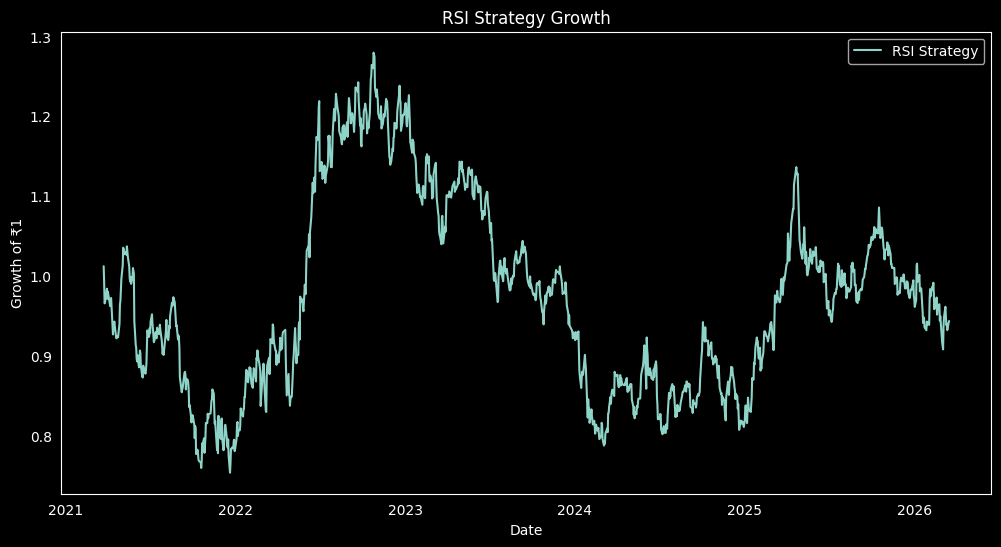

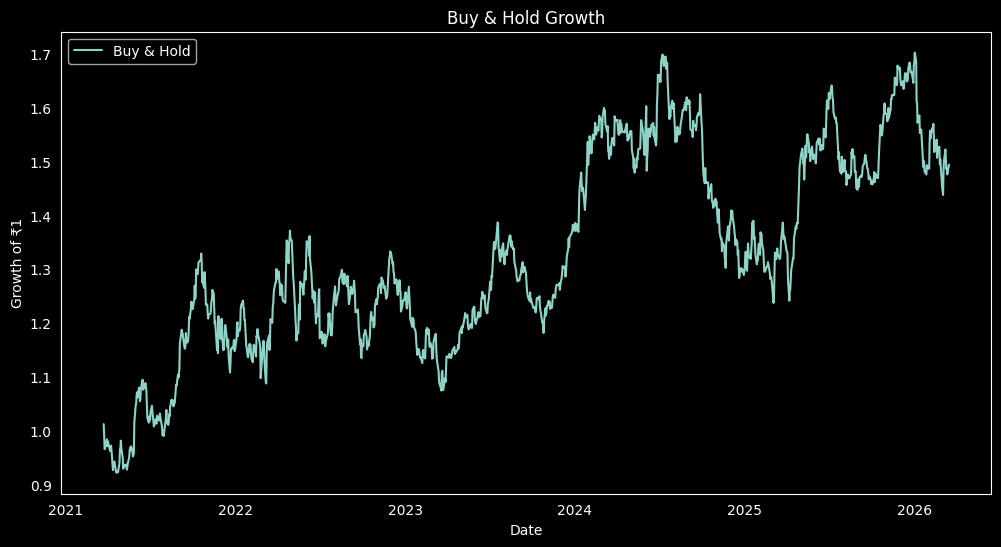

In [233]:
# Change
dfa['change'] = dfa['close'] - dfa['close'].shift(1)
# Gain and loss in change
dfa['gain'] = dfa['change'].apply(lambda x: x if x > 0 else 0)
dfa['loss'] = dfa['change'].apply(lambda x: x if x < 0 else 0)
dfa['loss'] = dfa['loss'] * -1
#average gain and loss
dfa['avg_gain'] = dfa['gain'].ewm(span=14, adjust=False).mean()
dfa['avg_loss'] = dfa['loss'].ewm(span=14, adjust=False).mean()
dfa.dropna(inplace=True)
# Calculating Rsi
dfa['rs'] = dfa['avg_gain'] / dfa['avg_loss']
dfa['rsi'] = 100 - (100 / (1 + dfa['rs']))
# Create signal column
dfa['signal'] = np.where(dfa['rsi'] < 30, 1,
                  np.where(dfa['rsi'] > 70, -1, np.nan))

# Forward fill to maintain position
dfa['position'] = dfa['signal'].ffill()

# Replace initial NaN with 0 (no trade at start)
dfa['position'] = dfa['position'].fillna(0)

# Shift to avoid lookahead bias
dfa['position'] = dfa['position'].shift(1)

# Returns
dfa['returns'] = dfa['close'].pct_change()

# cum_return
dfa['cum_growth'] = (1 +dfa['returns']).cumprod()

# strategy returns
dfa['strategy_return'] = dfa['returns'] * dfa['position']

# growth
dfa['growth'] = 1 + dfa['strategy_return']

#cum growth
dfa['rsi_cum_growth'] = dfa['growth'].cumprod()

rsi_strategy_returns =  dfa['rsi_cum_growth'][-1] -1
rsi_buy_hold = dfa['cum_growth'][-1] -1
print("RSI Strategy Returns = ", rsi_strategy_returns)
print("RSI Buy Hold Returns = ", rsi_buy_hold)

# RSI Strategy Plot
plt.figure(figsize=(12,6))
plt.plot(dfa['rsi_cum_growth'], label='RSI Strategy')
plt.title('RSI Strategy Growth')
plt.ylabel('Growth of ₹1')
plt.xlabel('Date')
plt.legend()
plt.grid()
plt.show()

# Buy & Hold Plot
plt.figure(figsize=(12,6))
plt.plot(dfa['cum_growth'], label='Buy & Hold',)
plt.title('Buy & Hold Growth')
plt.ylabel('Growth of ₹1')
plt.xlabel('Date')
plt.legend()
plt.grid()
plt.show()

# Breakout Strategy

In [234]:
df = yf.download('JWL.NS',start = '2021-06-01',end = '2024-06-01')

[*********************100%***********************]  1 of 1 completed


In [235]:
df.columns = df.columns.droplevel(1)
df.columns = df.columns.str.lower()
df.drop(columns=['open','volume'], inplace=True)
df.index = pd.to_datetime(df.index)

In [236]:
df['resistance'] = df['high'].rolling(15).max().shift(1)
df['support'] = df['low'].rolling(15).min().shift(1)
df.dropna(inplace=True)

In [237]:
df['signal'] = np.where(df['close'] > df['resistance'], 1,
                 np.where(df['close'] < df['support'], 0, np.nan))

In [238]:
df['position'] = df['signal'].shift(1)

In [239]:
df['returns'] = df['close'].pct_change()

In [240]:
df['strategy_return'] = df['returns'] * df['position']

In [241]:
df['strategy_growth'] = 1 + df['strategy_return']

In [242]:
df['strategy_cum_growth'] = df['growth'].cumprod()

KeyError: 'growth'

In [ ]:
df['cum_growth'][-1]